In [1]:
import zipfile


# Unzip all contents into the current directory
with zipfile.ZipFile("edge_impulse_augmented.zip", 'r') as zip_ref:
    zip_ref.extractall('edge_impulse_augmented')


In [2]:
print("hello world")

hello world


In [3]:
import os
import sys
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers.legacy import Adam

2026-06-13 18:41:49.131031: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-13 18:41:49.194121: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-13 18:41:49.561657: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-13 18:41:49.561721: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-13 18:41:49.565247: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [4]:
DATA_ROOT  = Path("./edge_impulse_augmented")    # folder containing your train/ and val/ subfolders
OUTPUT_DIR = Path("./student_output")  # where models and re-split data will be saved

EPOCHS     = 30
BATCH_SIZE = 32
LR         = 0.0005
SEED       = 42

In [5]:
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

SPLIT_DIR   = OUTPUT_DIR / "split_data"
IMG_SIZE    = (45, 45)
NUM_CLASSES = 16

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.15

TEMPERATURE = 4.0
ALPHA       = 0.7

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


=== Step 1: Collecting and re-splitting data ===
Found 16 classes: ['1.0M_ohm', '1.2M_ohm', '1.5K_ohm', '100_ohm', '10K_ohm', '1K_ohm', '1_ohm', '20K_ohm', '27K_ohm', '300_ohm', '30K_ohm', '33K_ohm', '4.7K_ohm', '43_ohm', '51_ohm', '8.2K_ohm']
  1.0M_ohm              total= 562  train= 449  val= 84  test= 29
  1.2M_ohm              total= 567  train= 453  val= 85  test= 29
  1.5K_ohm              total= 569  train= 455  val= 85  test= 29
  100_ohm               total= 565  train= 452  val= 84  test= 29
  10K_ohm               total= 565  train= 452  val= 84  test= 29
  1K_ohm                total= 565  train= 452  val= 84  test= 29
  1_ohm                 total= 565  train= 452  val= 84  test= 29
  20K_ohm               total= 564  train= 451  val= 84  test= 29
  27K_ohm               total= 565  train= 452  val= 84  test= 29
  300_ohm               total= 566  train= 452  val= 84  test= 30
  30K_ohm               total= 568  train= 454  val= 85  test= 29
  33K_ohm               total

2026-06-13 18:41:57.999095: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-13 18:41:58.000018: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 1350 files belonging to 16 classes.
Found 467 files belonging to 16 classes.
Class order (label index 0..15): ['1.0M_ohm', '1.2M_ohm', '1.5K_ohm', '100_ohm', '10K_ohm', '1K_ohm', '1_ohm', '20K_ohm', '27K_ohm', '300_ohm', '30K_ohm', '33K_ohm', '4.7K_ohm', '43_ohm', '51_ohm', '8.2K_ohm']

=== Step 2b: Visual inspection ===
  Saved → student_output/inspect_val.png


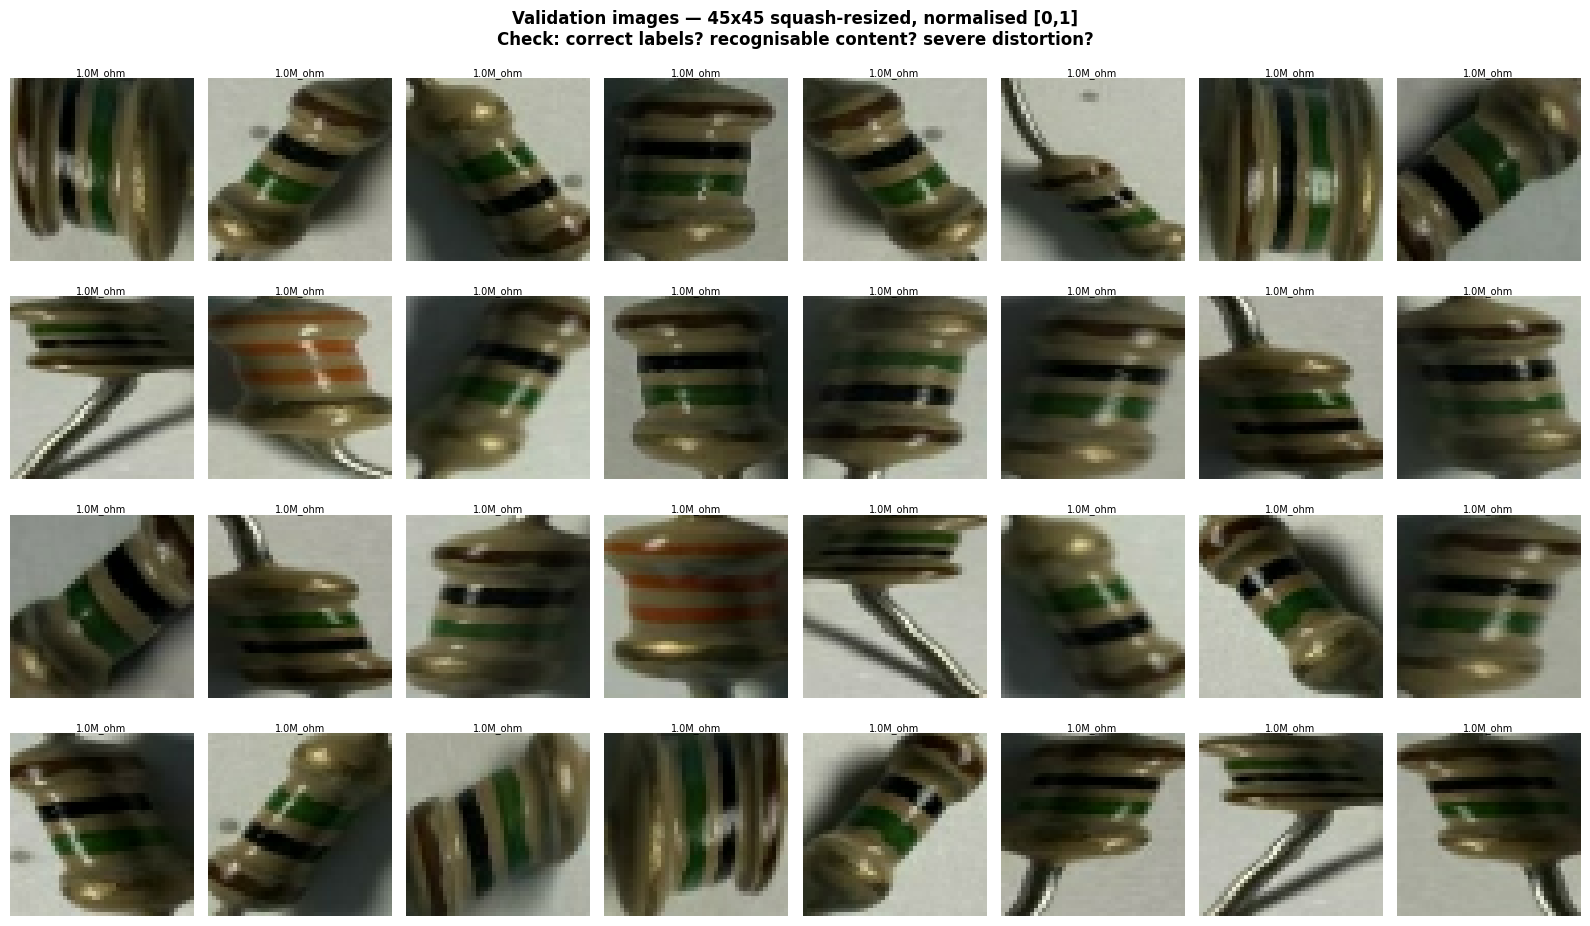


Per-class pixel statistics (val set) — means should be roughly similar:
  Class                   mean    std    n_imgs
  1.0M_ohm                0.374   0.098   84
  1.2M_ohm                0.365   0.055   85
  1.5K_ohm                0.346   0.083   85
  100_ohm                 0.367   0.086   84
  10K_ohm                 0.348   0.092   84
  1K_ohm                  0.378   0.056   84
  1_ohm                   0.326   0.065   84
  20K_ohm                 0.388   0.075   84
  27K_ohm                 0.400   0.053   84
  300_ohm                 0.369   0.075   84
  30K_ohm                 0.369   0.056   85
  33K_ohm                 0.369   0.068   84
  4.7K_ohm                0.367   0.047   85
  43_ohm                  0.360   0.072   85
  51_ohm                  0.356   0.070   84
  8.2K_ohm                0.438   0.086   85

>>> Inspect the grids above before proceeding.


In [6]:
#Image Gen
# ---------------------------------------------------------------------------
print("\n=== Step 1: Collecting and re-splitting data ===")

def collect_images(root: Path) -> dict:
    class_map = {}
    for split_dir in ["train", "val", "test"]:
        split_path = root / split_dir
        if not split_path.exists():
            continue
        for class_dir in sorted(split_path.iterdir()):
            if not class_dir.is_dir():
                continue
            name = class_dir.name
            imgs = [p for p in class_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS]
            class_map.setdefault(name, []).extend(imgs)
    return class_map

class_map = collect_images(DATA_ROOT)

if not class_map:
    print(f"ERROR: No images found under {DATA_ROOT}. Check your DATA_ROOT path.")
    sys.exit(1)

classes = sorted(class_map.keys())
print(f"Found {len(classes)} classes: {classes}")

if len(classes) != NUM_CLASSES:
    print(f"WARNING: expected {NUM_CLASSES} classes but found {len(classes)}. "
          f"Update NUM_CLASSES at the top if needed.")

for split in ["train", "val", "test"]:
    (SPLIT_DIR / split).mkdir(parents=True, exist_ok=True)

total_imgs = 0
for class_name, paths in class_map.items():
    random.shuffle(paths)
    n       = len(paths)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    splits  = {
        "train": paths[:n_train],
        "val":   paths[n_train:n_train + n_val],
        "test":  paths[n_train + n_val:],
    }
    for split_name, split_paths in splits.items():
        dest_dir = SPLIT_DIR / split_name / class_name
        dest_dir.mkdir(parents=True, exist_ok=True)
        for src in split_paths:
            shutil.copy2(src, dest_dir / src.name)
    total_imgs += n
    print(f"  {class_name:20s}  total={n:4d}  "
          f"train={len(splits['train']):4d}  "
          f"val={len(splits['val']):3d}  "
          f"test={len(splits['test']):3d}")

print(f"\nTotal images: {total_imgs}")

# ---------------------------------------------------------------------------
# STEP 2 — DATA PIPELINE
# ---------------------------------------------------------------------------
print("\n=== Step 2: Building data pipelines ===")

def make_dataset(split: str, training: bool = False):
    ds = tf.keras.utils.image_dataset_from_directory(
        str(SPLIT_DIR / split),
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        shuffle=training,
        seed=SEED,
        crop_to_aspect_ratio=False,   # squash, not crop — matches Edge Impulse
    )
    # Normalise [0,255] -> [0,1]. No augmentation — the dataset is already
    # augmented, and for resistor band classification flipping/rotating
    # changes the apparent band order and would corrupt labels.
    normalise = layers.Rescaling(1.0 / 255)
    ds = ds.map(lambda x, y: (normalise(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


# Build datasets
train_ds = make_dataset("train", training=True)
val_ds   = make_dataset("val",   training=False)
test_ds  = make_dataset("test",  training=False)

# Grab class names from Keras (alphabetical = same order as label indices)
class_names = sorted([d.name for d in (SPLIT_DIR / "train").iterdir() if d.is_dir()])
print(f"Class order (label index 0..{len(class_names)-1}): {class_names}")

# ---------------------------------------------------------------------------
# STEP 2b — VISUAL INSPECTION
# Run this cell to sanity-check images BEFORE training.
# Look for:
#   - Wrong labels (subfolder name mismatch)
#   - Severe squash distortion (very non-square source images)
#   - All-black / all-white / corrupted images
#   - Augmentation that looks too aggressive
# ---------------------------------------------------------------------------
print("\n=== Step 2b: Visual inspection ===")

def show_grid(ds, class_names, title, n_cols=8, n_rows=4, save_path=None):
    n_show   = n_cols * n_rows
    batch_imgs, batch_labels = next(iter(ds.unbatch().batch(n_show)))
    imgs   = batch_imgs.numpy()
    labels = batch_labels.numpy()
    preds  = [class_names[np.argmax(l)] for l in labels]
    n      = len(imgs)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(np.clip(imgs[i], 0, 1), interpolation="nearest")
            ax.set_title(preds[i], fontsize=7, pad=2)
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved → {save_path}")
    plt.show()

# Val images
show_grid(
    val_ds, class_names,
    title="Validation images — 45x45 squash-resized, normalised [0,1]\n"
          "Check: correct labels? recognisable content? severe distortion?",
    save_path=str(OUTPUT_DIR / "inspect_val.png"),
)

# Per-class pixel mean — flags badly normalised or corrupted classes
print("\nPer-class pixel statistics (val set) — means should be roughly similar:")
print(f"  {'Class':<22}  mean    std    n_imgs")
class_stats = {c: [] for c in class_names}
for imgs_b, labels_b in val_ds.unbatch().batch(256):
    for img, label in zip(imgs_b.numpy(), labels_b.numpy()):
        cls = class_names[np.argmax(label)]
        class_stats[cls].append(float(np.mean(img)))

for cls, vals in class_stats.items():
    if vals:
        print(f"  {cls:<22}  {np.mean(vals):.3f}   {np.std(vals):.3f}   {len(vals)}")

print("\n>>> Inspect the grids above before proceeding.")


In [7]:
# Teacher Model Creation
# ---------------------------------------------------------------------------
print("\n=== Step 3: Building teacher model ===")

def build_teacher(input_shape=(45, 45, 3), num_classes=16):
    model = tf.keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Conv2D(
            16, kernel_size=3,
            kernel_constraint=tf.keras.constraints.MaxNorm(1),
            padding="same", activation="relu",
        ),
        layers.MaxPooling2D(pool_size=2, strides=2, padding="same"),
        layers.Conv2D(
            32, kernel_size=3,
            kernel_constraint=tf.keras.constraints.MaxNorm(1),
            padding="same", activation="relu",
        ),
        layers.MaxPooling2D(pool_size=2, strides=2, padding="same"),
        layers.Flatten(),
        layers.Dropout(0.33),
        layers.Dense(num_classes, name="y_pred", activation="softmax"),
    ], name="teacher")
    return model

teacher = build_teacher(num_classes=len(class_names))
teacher.summary()
print(f"Teacher params: {teacher.count_params():,}")

# ---------------------------------------------------------------------------
# STEP 4 — TRAIN TEACHER
# ---------------------------------------------------------------------------
print("\n=== Step 4: Training teacher ===")

# Save as SavedModel format (more reliable than .h5 for subclassed models)
teacher_ckpt = str(OUTPUT_DIR / "teacher_savedmodel")

teacher.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LR, beta_1=0.9, beta_2=0.999),
    metrics=["accuracy"],
)

teacher_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        teacher_ckpt, monitor="val_accuracy", save_best_only=True,
        save_format="tf", verbose=1,
    ),
]

teacher.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=teacher_callbacks,
    verbose=2,
)

teacher = tf.keras.models.load_model(teacher_ckpt)
teacher.trainable = False

loss, acc = teacher.evaluate(test_ds, verbose=0)
print(f"\nTeacher test accuracy: {acc*100:.2f}%  (loss: {loss:.4f})")
print(f"Teacher saved → {teacher_ckpt}")


=== Step 3: Building teacher model ===
Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 45, 45, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 23, 23, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 23, 23, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 4608)              0         
                                                                 
 dropout (Dropout) 

INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


227/227 - 4s - loss: 2.4790 - accuracy: 0.2281 - val_loss: 1.9252 - val_accuracy: 0.4496 - lr: 5.0000e-04 - 4s/epoch - 18ms/step
Epoch 2/30

Epoch 2: val_accuracy improved from 0.44963 to 0.62963, saving model to student_output/teacher_savedmodel
INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


227/227 - 3s - loss: 1.6342 - accuracy: 0.5308 - val_loss: 1.4088 - val_accuracy: 0.6296 - lr: 5.0000e-04 - 3s/epoch - 14ms/step
Epoch 3/30

Epoch 3: val_accuracy improved from 0.62963 to 0.74444, saving model to student_output/teacher_savedmodel
INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


...

227/227 - 3s - loss: 0.0551 - accuracy: 0.9909 - val_loss: 0.1129 - val_accuracy: 0.9778 - lr: 2.5000e-04 - 3s/epoch - 14ms/step
Epoch 26/30

Epoch 26: val_accuracy did not improve from 0.97778
227/227 - 3s - loss: 0.0503 - accuracy: 0.9920 - val_loss: 0.1096 - val_accuracy: 0.9763 - lr: 2.5000e-04 - 3s/epoch - 12ms/step
Epoch 27/30

Epoch 27: val_accuracy improved from 0.97778 to 0.98074, saving model to student_output/teacher_savedmodel
INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


227/227 - 3s - loss: 0.0524 - accuracy: 0.9917 - val_loss: 0.0942 - val_accuracy: 0.9807 - lr: 2.5000e-04 - 3s/epoch - 15ms/step
Epoch 28/30

Epoch 28: val_accuracy did not improve from 0.98074
227/227 - 3s - loss: 0.0527 - accuracy: 0.9909 - val_loss: 0.1147 - val_accuracy: 0.9807 - lr: 2.5000e-04 - 3s/epoch - 13ms/step
Epoch 29/30

Epoch 29: val_accuracy did not improve from 0.98074
227/227 - 3s - loss: 0.0462 - accuracy: 0.9916 - val_loss: 0.0983 - val_accuracy: 0.9793 - lr: 2.5000e-04 - 3s/epoch - 12ms/step
Epoch 30/30

Epoch 30: val_accuracy improved from 0.98074 to 0.98222, saving model to student_output/teacher_savedmodel
INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


INFO:tensorflow:Assets written to: student_output/teacher_savedmodel/assets


227/227 - 3s - loss: 0.0475 - accuracy: 0.9919 - val_loss: 0.1026 - val_accuracy: 0.9822 - lr: 2.5000e-04 - 3s/epoch - 15ms/step

Teacher test accuracy: 97.22%  (loss: 0.1050)
Teacher saved → student_output/teacher_savedmodel


In [8]:
# Student Model Creation
# ---------------------------------------------------------------------------
print("\n=== Step 5: Building student model ===")

def build_student(input_shape=(45, 45, 3), num_classes=16):
    inp = layers.Input(shape=input_shape, name="input")
    x = layers.SeparableConv2D(8,  kernel_size=3, padding="same", use_bias=False, name="sep_conv1")(inp)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2, padding="same", name="pool1")(x)
    x = layers.SeparableConv2D(16, kernel_size=3, padding="same", use_bias=False, name="sep_conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling2D(pool_size=2, strides=2, padding="same", name="pool2")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dropout(0.33)(x)
    out = layers.Dense(num_classes, activation="softmax", name="y_pred")(x)
    return Model(inputs=inp, outputs=out, name="student")

student = build_student(num_classes=len(class_names))
student.summary()
print(f"Student params:  {student.count_params():,}")
print(f"Compression:     {teacher.count_params() / student.count_params():.1f}x fewer params")

# ---------------------------------------------------------------------------
# STEP 6 — DISTILLATION TRAINING
# Fix: save student weights separately (not the DistillationModel wrapper)
# ---------------------------------------------------------------------------
print("\n=== Step 6: Distillation training ===")

class DistillationModel(Model):
    def __init__(self, teacher, student, temperature, alpha):
        super().__init__()
        self.teacher     = teacher
        self.student     = student
        self.temperature = temperature
        self.alpha       = alpha

    def compile(self, optimizer, metrics):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.hard_loss = tf.keras.losses.CategoricalCrossentropy()
        self.soft_loss = tf.keras.losses.KLDivergence()

    def train_step(self, data):
        images, labels = data
        teacher_probs = self.teacher(images, training=False)
        soft_targets  = tf.nn.softmax(
            tf.math.log(tf.clip_by_value(teacher_probs, 1e-10, 1.0)) / self.temperature
        )
        with tf.GradientTape() as tape:
            student_logits = self.student(images, training=True)
            soft_preds     = tf.nn.softmax(
                tf.math.log(tf.clip_by_value(student_logits, 1e-10, 1.0)) / self.temperature
            )
            loss_soft = self.soft_loss(soft_targets, soft_preds) * (self.temperature ** 2)
            loss_hard = self.hard_loss(labels, student_logits)
            loss      = self.alpha * loss_soft + (1.0 - self.alpha) * loss_hard

        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        self.compiled_metrics.update_state(labels, student_logits)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss, "loss_soft": loss_soft, "loss_hard": loss_hard})
        return results

    def test_step(self, data):
        images, labels = data
        student_logits = self.student(images, training=False)
        loss = self.hard_loss(labels, student_logits)
        self.compiled_metrics.update_state(labels, student_logits)
        results = {m.name: m.result() for m in self.metrics}
        results["loss"] = loss
        return results


# Fix: checkpoint saves only the inner student (a clean Functional model)
student_weights_ckpt = str(OUTPUT_DIR / "best_student_weights.weights.h5")

class SaveStudentWeights(tf.keras.callbacks.Callback):
    """Saves only student weights when val_accuracy improves."""
    def __init__(self, filepath):
        super().__init__()
        self.filepath    = filepath
        self.best        = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy", 0)
        if val_acc > self.best:
            self.best = val_acc
            self.model.student.save_weights(self.filepath)
            print(f"\n  Student weights improved to {val_acc:.4f} — saved.")

distiller = DistillationModel(
    teacher=teacher, student=student,
    temperature=TEMPERATURE, alpha=ALPHA,
)
distiller.compile(
    optimizer=Adam(learning_rate=LR, beta_1=0.9, beta_2=0.999),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")],
)

distiller.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1
        ),
        SaveStudentWeights(student_weights_ckpt),
    ],
    verbose=2,
)

# Rebuild clean student, load best weights, compile before evaluate
best_student = build_student(num_classes=len(class_names))
best_student.load_weights(student_weights_ckpt)
best_student.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LR, beta_1=0.9, beta_2=0.999),
    metrics=["accuracy"],
)

loss, acc = best_student.evaluate(test_ds, verbose=0)
print(f"\nStudent test accuracy: {acc*100:.2f}%  (loss: {loss:.4f})")

# Save student as both SavedModel and .h5
student_savedmodel = str(OUTPUT_DIR / "student_savedmodel")
best_student.save(student_savedmodel, save_format="tf")
best_student.save(str(OUTPUT_DIR / "student_model.h5"))   # Sequential/Functional — safe
print(f"Student saved → {student_savedmodel}  +  output/student_model.h5")

# ---------------------------------------------------------------------------
# STEP 7 — EXPORT STUDENT TO TFLITE
# ---------------------------------------------------------------------------
print("\n=== Step 7: Exporting student to TFLite ===")

tflite_path = str(OUTPUT_DIR / "student_model.tflite")
converter   = tf.lite.TFLiteConverter.from_keras_model(best_student)
tflite_model = converter.convert()
with open(tflite_path, "wb") as f:
    f.write(tflite_model)
print(f"TFLite saved → {tflite_path}  ({len(tflite_model)/1024:.1f} KB)")

print("\nVerifying TFLite on test set …")
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_idx = interpreter.get_input_details()[0]["index"]
out_idx = interpreter.get_output_details()[0]["index"]

correct, total = 0, 0
for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        interpreter.set_tensor(inp_idx, img[np.newaxis].astype(np.float32))
        interpreter.invoke()
        pred = interpreter.get_tensor(out_idx)[0]
        if np.argmax(pred) == np.argmax(label):
            correct += 1
        total += 1

print(f"TFLite test accuracy: {correct}/{total} = {correct/total*100:.2f}%")

# ---------------------------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("DONE")
print("="*60)
print(f"  Teacher params : {teacher.count_params():,}")
print(f"  Student params : {best_student.count_params():,}")
print(f"  Compression    : {teacher.count_params() / best_student.count_params():.1f}x")
print(f"\n  Outputs in {OUTPUT_DIR}/")
print(f"    inspect_val.png              ← processed val images grid")
print(f"    inspect_train_augmented.png  ← augmented train images grid")
print(f"    teacher_savedmodel/          ← trained teacher")
print(f"    student_model.h5             ← trained student")
print(f"    student_model.tflite         ← upload this to Edge Impulse")
print(f"\nNext step: INT8 quantisation for further size reduction.")



=== Step 5: Building student model ===
Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 45, 45, 3)]       0         
                                                                 
 sep_conv1 (SeparableConv2D  (None, 45, 45, 8)         51        
 )                                                               
                                                                 
 bn1 (BatchNormalization)    (None, 45, 45, 8)         32        
                                                                 
 relu1 (ReLU)                (None, 45, 45, 8)         0         
                                                                 
 pool1 (MaxPooling2D)        (None, 23, 23, 8)         0         
                                                                 
 sep_conv2 (SeparableConv2D  (None, 23, 23, 16)        200       
 )                 

INFO:tensorflow:Assets written to: student_output/student_savedmodel/assets


Student saved → student_output/student_savedmodel  +  output/student_model.h5

=== Step 7: Exporting student to TFLite ===


/home/brookewd/.local/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: /tmp/tmpip84frxn/assets


INFO:tensorflow:Assets written to: /tmp/tmpip84frxn/assets


TFLite saved → student_output/student_model.tflite  (148.9 KB)

Verifying TFLite on test set …
TFLite test accuracy: 441/467 = 94.43%

DONE
  Teacher params : 78,832
  Student params : 37,227
  Compression    : 2.1x

  Outputs in student_output/
    inspect_val.png              ← processed val images grid
    inspect_train_augmented.png  ← augmented train images grid
    teacher_savedmodel/          ← trained teacher
    student_model.h5             ← trained student
    student_model.tflite         ← upload this to Edge Impulse

Next step: INT8 quantisation for further size reduction.


2026-06-13 18:44:56.397121: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:44:56.397375: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:44:56.400861: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpip84frxn
2026-06-13 18:44:56.403316: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:44:56.403353: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpip84frxn
2026-06-13 18:44:56.408511: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-06-13 18:44:56.409838: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:44:56.448174: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpip84frxn
2026-06

In [9]:
import math
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

# Reload student if running in a fresh session
best_student = tf.keras.models.load_model("student_output/student_savedmodel")

# Count training steps properly from a tf.data.Dataset
train_size = sum(1 for _ in train_ds.unbatch())
steps_per_epoch = math.ceil(train_size / BATCH_SIZE)

pruning_epochs = 30

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.05,
        final_sparsity=0.40,
        begin_step=steps_per_epoch * 2,
        end_step=steps_per_epoch * 18,
    )
}

student_for_pruning = keras.models.clone_model(best_student)
student_for_pruning.set_weights(best_student.get_weights())

pruned_distilled_model = prune_low_magnitude(student_for_pruning, **pruning_params)
pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",   # one-hot labels, not sparse
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
    )
]

pruning_history = pruned_distilled_model.fit(
    train_ds,
    validation_data=val_ds,      # use our existing val split, not validation_split=
    epochs=pruning_epochs,
    callbacks=pruning_callbacks,
    verbose=1,
)

Epoch 1/30
227/227 [==============================] - 6s 13ms/step - loss: 0.2675 - accuracy: 0.9193 - val_loss: 0.2395 - val_accuracy: 0.9415
Epoch 2/30
227/227 [==============================] - 3s 13ms/step - loss: 0.2466 - accuracy: 0.9229 - val_loss: 0.2217 - val_accuracy: 0.9452
Epoch 3/30
227/227 [==============================] - 3s 13ms/step - loss: 0.2496 - accuracy: 0.9222 - val_loss: 0.4874 - val_accuracy: 0.8415
Epoch 4/30
227/227 [==============================] - 0s 2ms/step - loss: 0.2499 - accuracy: 0.9229 - val_loss: 0.2381 - val_accuracy: 0.9296
Epoch 5/30
227/227 [==============================] - 3s 15ms/step - loss: 0.2674 - accuracy: 0.9164 - val_loss: 0.3405 - val_accuracy: 0.8948


In [10]:
import os
import numpy as np
from sklearn.metrics import accuracy_score

# ---------------------------------------------------------------------------
# Extract numpy arrays from tf.data.Dataset
# (the lab functions expect X/y arrays, not tf.data pipelines)
# ---------------------------------------------------------------------------
def dataset_to_numpy(ds):
    images, labels = [], []
    for img_batch, label_batch in ds:
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())
    X = np.concatenate(images, axis=0)
    y = np.concatenate(labels, axis=0)
    # Convert one-hot labels to integer class indices (what evaluate_tflite_model expects)
    y_int = np.argmax(y, axis=1)
    return X, y_int

print("Extracting arrays from datasets (this may take a moment)...")
X_train, y_train = dataset_to_numpy(train_ds)
X_val,   y_val   = dataset_to_numpy(val_ds)
X_test,  y_test  = dataset_to_numpy(test_ds)
print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# ---------------------------------------------------------------------------
# Lab functions — unchanged from your original
# ---------------------------------------------------------------------------
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale,  input_zero_point  = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    y_pred = []
    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        if input_details["dtype"] == np.int8:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        elif input_details["dtype"] == np.uint8:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(0, len(X_train), 32):
        yield [X_train[i:i+32]]

Extracting arrays from datasets (this may take a moment)...
X_train: (7247, 45, 45, 3)  y_train: (7247,)
X_val:   (1350, 45, 45, 3)    y_val:   (1350,)
X_test:  (467, 45, 45, 3)   y_test:  (467,)


In [11]:
pruned_with_mask_tflite  = convert_to_tflite_fp32(pruned_distilled_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_pruned_model = strip_pruning(pruned_distilled_model)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite   = converter.convert()
stripped_sparse_size_kb  = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy:    {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB):   {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy:     {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB):    {stripped_sparse_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmp1w3ye_fl/assets


INFO:tensorflow:Assets written to: /tmp/tmp1w3ye_fl/assets
2026-06-13 18:45:21.855735: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:45:21.855829: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:45:21.856088: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1w3ye_fl
2026-06-13 18:45:21.862763: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:45:21.862822: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1w3ye_fl
2026-06-13 18:45:21.883752: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:45:21.997248: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1w3ye_fl
2026-06-13 18:45:22.047419: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp1ac7uki_/assets


INFO:tensorflow:Assets written to: /tmp/tmp1ac7uki_/assets


Pruned distilled model with mask accuracy:    0.9422
Pruned distilled model with mask size (KB):   298.81
Stripped sparse distilled model accuracy:     0.9422
Stripped sparse distilled model size (KB):    148.89


2026-06-13 18:45:23.251445: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:45:23.251512: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:45:23.251688: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1ac7uki_
2026-06-13 18:45:23.253310: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:45:23.253331: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1ac7uki_
2026-06-13 18:45:23.256961: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:45:23.286485: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1ac7uki_
2026-06-13 18:45:23.298374: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 46688 m

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpfpd1jz25/assets


INFO:tensorflow:Assets written to: /tmp/tmpfpd1jz25/assets
/home/brookewd/.local/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-06-13 18:45:24.249402: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:45:24.249460: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:45:24.249647: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfpd1jz25
2026-06-13 18:45:24.251290: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:45:24.251309: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfpd1jz25
2026-06-13 18:45:24.255198: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:45:24.

Stripped Sparse + INT8 Accuracy: 0.9379
Stripped Sparse + INT8 Size (KB): 41.63


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INFO:tensorflow:Assets written to: /tmp/tmp8tj27c7z/assets


INFO:tensorflow:Assets written to: /tmp/tmp8tj27c7z/assets
2026-06-13 18:45:29.721121: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:45:29.721212: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:45:29.721477: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8tj27c7z
2026-06-13 18:45:29.723022: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:45:29.723072: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8tj27c7z
2026-06-13 18:45:29.726449: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:45:29.752226: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8tj27c7z
2026-06-13 18:45:29.761773: I tensorflow/cc/saved_model/loader.cc:316] SavedModel


Model                        Size (KB)  vs Teacher    Accuracy
--------------------------------------------------------------
Teacher (fp32)                  310.79           —      97.22%
Student (fp32)                  148.89  2.1x smaller      94.43%
Stripped Sparse (INT8)           41.63  7.5x smaller      93.79%
Saved → student_output/confusion_Teacher_fp32.png


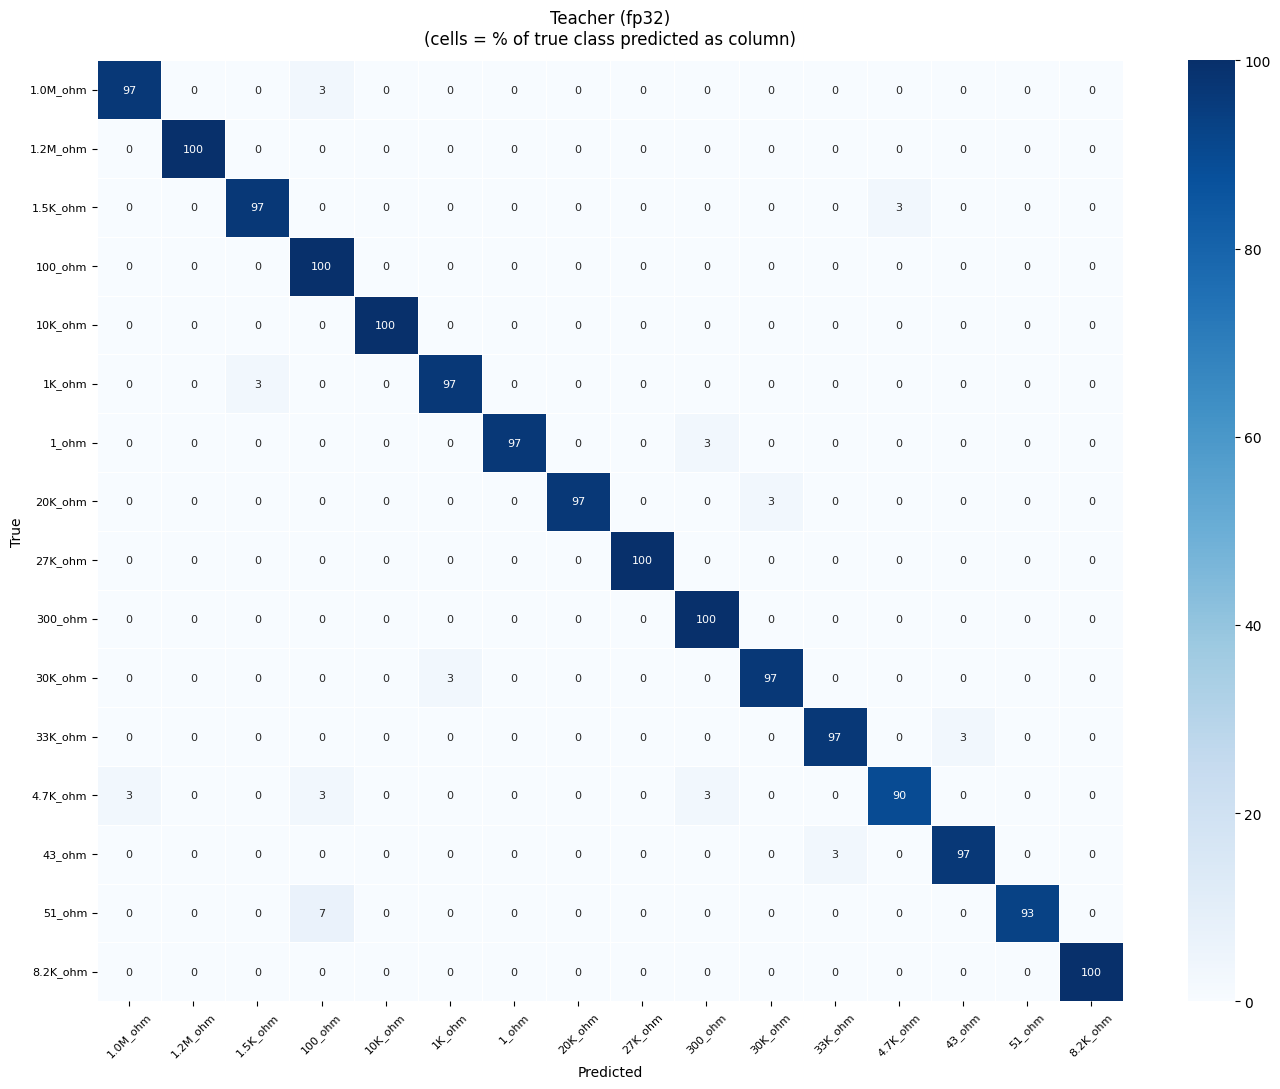

Saved → student_output/confusion_Student_fp32.png


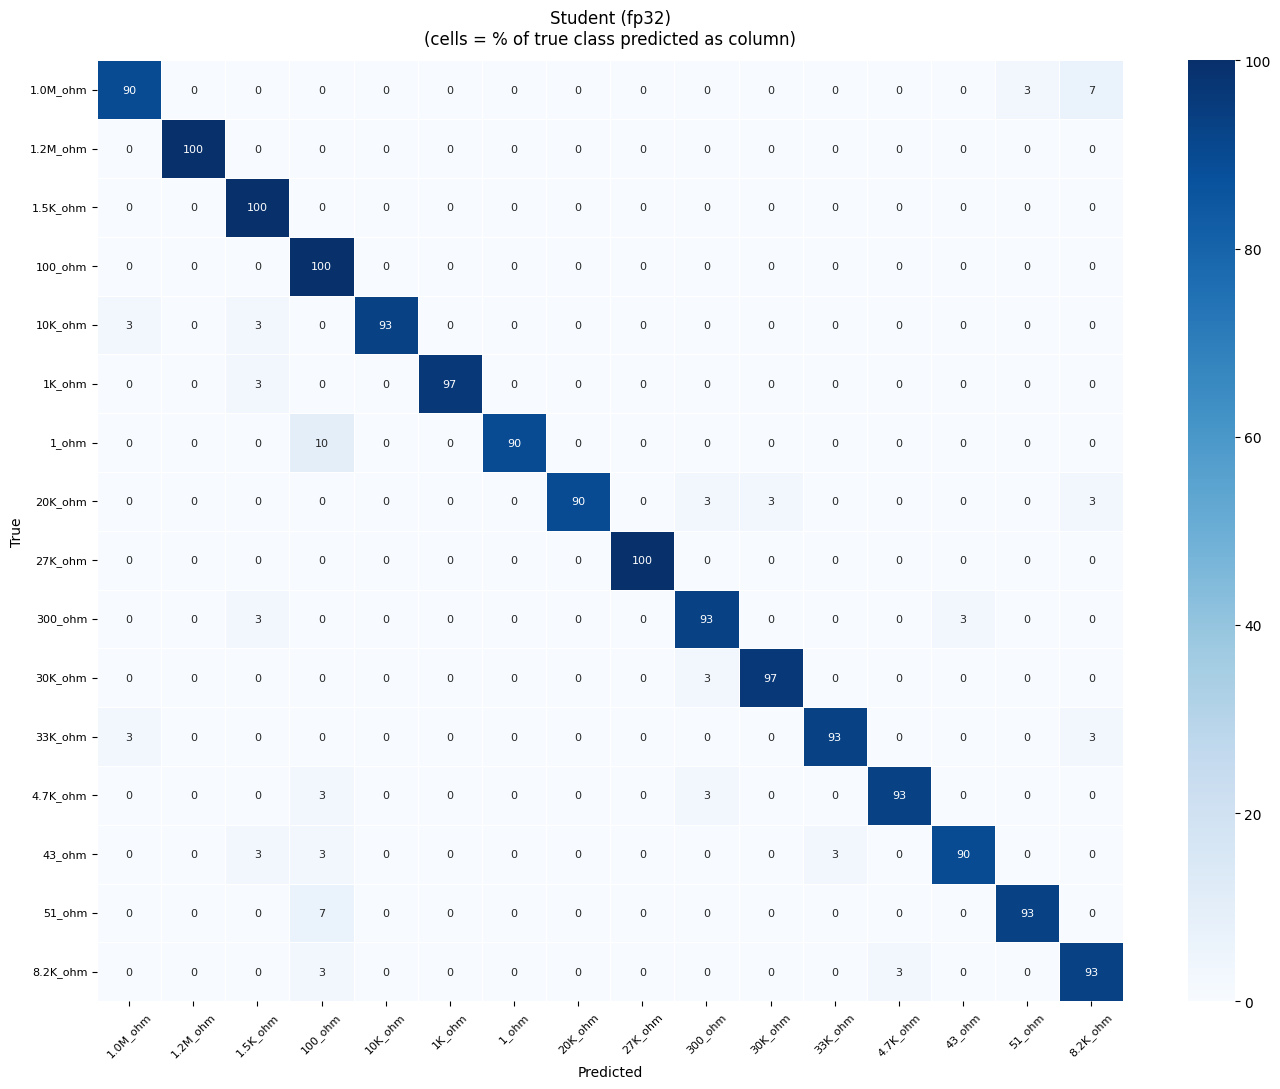

Saved → student_output/confusion_Stripped_Sparse_INT8.png


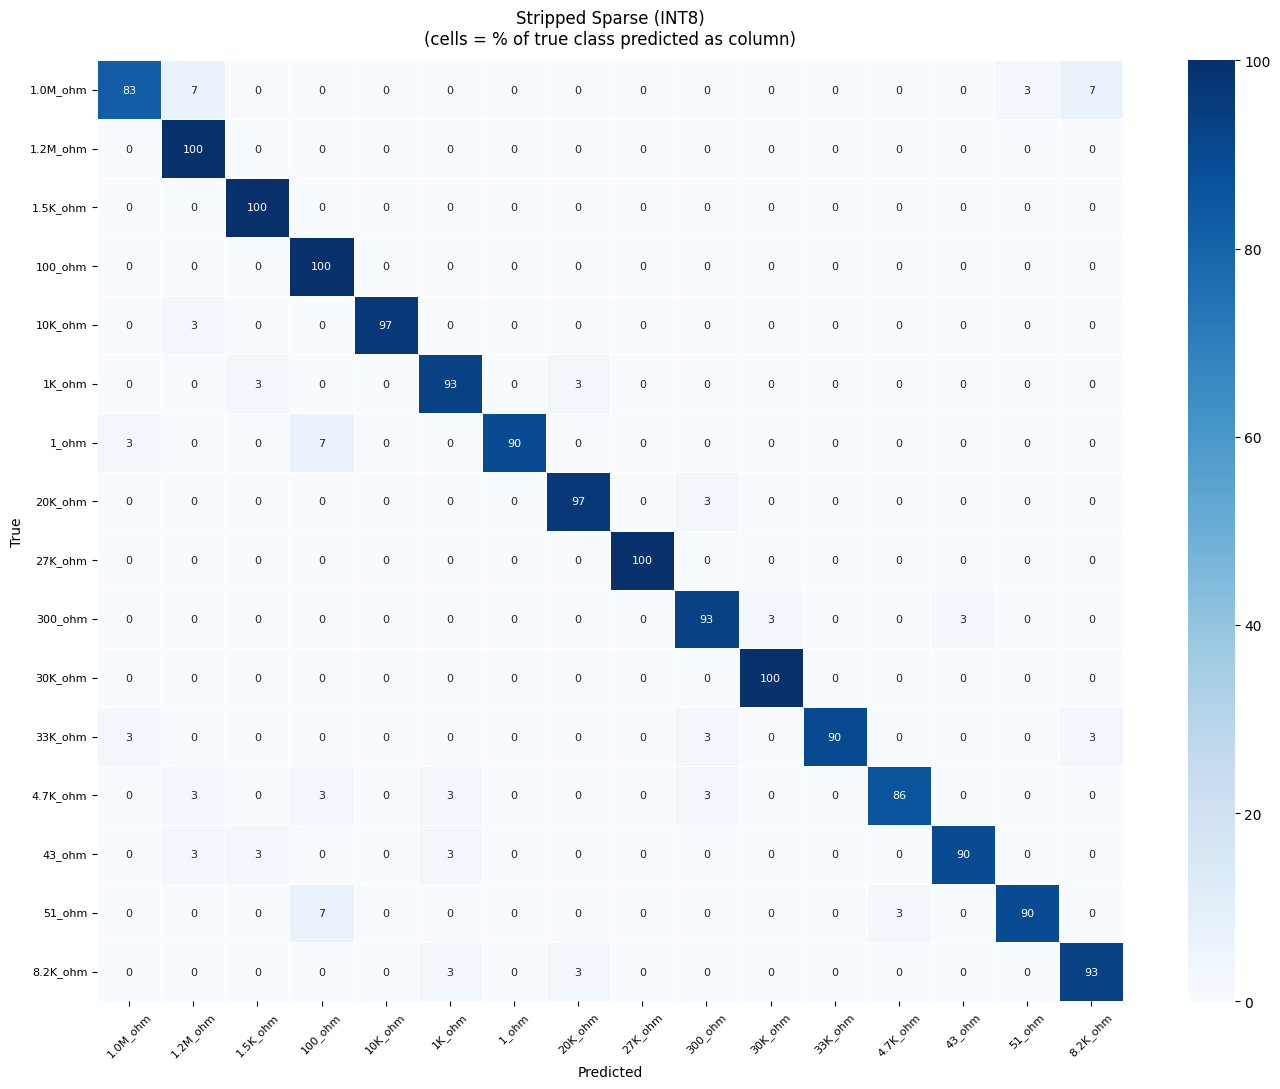

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------------------------------
# Original teacher + student tflite sizes (already saved to disk)
# ---------------------------------------------------------------------------
teacher_tflite_path = "student_output/teacher_savedmodel"  # we'll convert on the fly
student_tflite_path = "student_output/student_model.tflite"

# Convert teacher to tflite for fair size comparison
teacher_model = tf.keras.models.load_model("student_output/teacher_savedmodel")
teacher_tflite = convert_to_tflite_fp32(teacher_model)
teacher_size_kb = save_binary_model(teacher_tflite, "teacher_fp32.tflite")
teacher_acc, teacher_preds = evaluate_tflite_model(teacher_tflite, X_test, y_test)

student_tflite = open(student_tflite_path, "rb").read()
student_size_kb = os.path.getsize(student_tflite_path) / 1024.0
student_acc, student_preds = evaluate_tflite_model(student_tflite, X_test, y_test)

# ---------------------------------------------------------------------------
# Size + accuracy summary table
# ---------------------------------------------------------------------------
models = {
    "Teacher (fp32)":           (teacher_size_kb,          teacher_acc,          teacher_preds),
    "Student (fp32)":           (student_size_kb,           student_acc,          student_preds),
    "Stripped Sparse (INT8)":    (stripped_sparse_int8_size_kb,  stripped_sparse_int8_acc, stripped_sparse_int8_preds),
}

print(f"\n{'Model':<26}  {'Size (KB)':>10}  {'vs Teacher':>10}  {'Accuracy':>10}")
print("-" * 62)
for name, (size, acc, _) in models.items():
    ratio = f"{teacher_size_kb / size:.1f}x smaller" if size != teacher_size_kb else "—"
    print(f"{name:<26}  {size:>10.2f}  {ratio:>10}  {acc*100:>9.2f}%")

# ---------------------------------------------------------------------------
# Confusion matrices — one per model
# ---------------------------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    # Normalise to percentages per true class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(
        cm_norm, annot=True, fmt=".0f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax, vmin=0, vmax=100,
        annot_kws={"size": 8},
    )
    ax.set_title(f"{title}\n(cells = % of true class predicted as column)", fontsize=12, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)
    plt.tight_layout()
    safe_name = title.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "")
    path = f"student_output/confusion_{safe_name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")
    plt.show()

for name, (_, _, preds) in models.items():
    plot_confusion_matrix(y_test, preds, name, class_names)

In [14]:
import tensorflow as tf
interpreter = tf.lite.Interpreter(model_content=stripped_sparse_int8_tflite)
interpreter.allocate_tensors()
arena_bytes = interpreter._get_memory_info() if hasattr(interpreter, "_get_memory_info") else None
print(arena_bytes)


None


In [15]:
import time
times = []
for i in range(100):
    x = X_test[i:i+1]
    if interpreter.get_input_details()[0]["dtype"] == np.int8:
        scale, zp = interpreter.get_input_details()[0]["quantization"]
        x = (x / scale + zp).astype(np.int8)
    else:
        x = x.astype(np.float32)
    start = time.perf_counter()
    interpreter.set_tensor(interpreter.get_input_details()[0]["index"], x)
    interpreter.invoke()
    times.append(time.perf_counter() - start)
print(f"Avg latency: {np.mean(times)*1000:.3f} ms")

Avg latency: 0.081 ms


In [16]:
class_names = sorted([d.name for d in (SPLIT_DIR / "train").iterdir() if d.is_dir()])
print(class_names)

['1.0M_ohm', '1.2M_ohm', '1.5K_ohm', '100_ohm', '10K_ohm', '1K_ohm', '1_ohm', '20K_ohm', '27K_ohm', '300_ohm', '30K_ohm', '33K_ohm', '4.7K_ohm', '43_ohm', '51_ohm', '8.2K_ohm']


In [17]:
import os
print(os.path.getsize("distilled_stripped_sparse_int8.tflite") / 1024, "KB")

interpreter = tf.lite.Interpreter(model_path="distilled_stripped_sparse_int8.tflite")
interpreter.allocate_tensors()
print(interpreter.get_input_details())

41.6328125 KB
[{'name': 'serving_default_input:0', 'index': 0, 'shape': array([ 1, 45, 45,  3], dtype=int32), 'shape_signature': array([-1, 45, 45,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [18]:
# ---------------------------------------------------------------------------
# STEP 7b — EXPORT TEACHER TO TFLITE
# ---------------------------------------------------------------------------
print("\n=== Step 7b: Exporting teacher to TFLite ===")

teacher_tflite_path = str(OUTPUT_DIR / "teacher_model.tflite")
teacher_converter   = tf.lite.TFLiteConverter.from_saved_model(teacher_ckpt)
teacher_tflite_model = teacher_converter.convert()
with open(teacher_tflite_path, "wb") as f:
    f.write(teacher_tflite_model)
print(f"Teacher TFLite saved → {teacher_tflite_path}  ({len(teacher_tflite_model)/1024:.1f} KB)")

print("\nVerifying teacher TFLite on test set …")
teacher_interp = tf.lite.Interpreter(model_path=teacher_tflite_path)
teacher_interp.allocate_tensors()
t_inp_idx = teacher_interp.get_input_details()[0]["index"]
t_out_idx = teacher_interp.get_output_details()[0]["index"]

correct, total = 0, 0
for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        teacher_interp.set_tensor(t_inp_idx, img[np.newaxis].astype(np.float32))
        teacher_interp.invoke()
        pred = teacher_interp.get_tensor(t_out_idx)[0]
        if np.argmax(pred) == np.argmax(label):
            correct += 1
        total += 1

print(f"Teacher TFLite test accuracy: {correct}/{total} = {correct/total*100:.2f}%")


=== Step 7b: Exporting teacher to TFLite ===
Teacher TFLite saved → student_output/teacher_model.tflite  (310.8 KB)

Verifying teacher TFLite on test set …
Teacher TFLite test accuracy: 454/467 = 97.22%


2026-06-13 18:45:33.298909: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-13 18:45:33.298998: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-13 18:45:33.299194: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: student_output/teacher_savedmodel
2026-06-13 18:45:33.300443: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-13 18:45:33.300465: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: student_output/teacher_savedmodel
2026-06-13 18:45:33.303592: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-13 18:45:33.349767: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: student_output/teacher_savedmodel
2026-06-13 18:45:33.364483: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load fo